# 21_E13 - Pipeline común de inferencia multiplanar

Este notebook arma el primer pipeline común para usar los dos modelos finales del proyecto:

- **Sagital SPIDER**: checkpoint consolidado en E12.
- **Axial T2 Al-Kafri/Sudirman**: checkpoint final limpio E10.

El objetivo no es entrenar, sino estandarizar inferencia, overlays, métricas rápidas y *quality flags* para avanzar hacia el agente IA / MVP.

Salidas principales:

- `results/E13_multiplanar_inference_pipeline/E13_multiplanar_pipeline_report.json`
- `docs/E13_multiplanar_inference_pipeline_conclusion.md`
- figuras de ejemplo sagital y axial en `figures/`


In [1]:
# Instalación segura de dependencias en Colab
try:
    import SimpleITK  # noqa
    import pydicom  # noqa
    import skimage  # noqa
    import scipy  # noqa
except Exception:
    %pip install -q SimpleITK pydicom scikit-image scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.7 MB/s eta 0:00:00


In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

import SimpleITK as sitk
import pydicom
from skimage.transform import resize
from scipy import ndimage as ndi

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

PFI_ROOT = Path("/content/drive/MyDrive/PFI_MVP")

SPIDER_ROOT = PFI_ROOT / "data" / "SPIDER"
E9_ROOT = PFI_ROOT / "results" / "E9_alkafri_axial_t2_final_labels_baseline"
E5_MULTICLASS_ROOT = PFI_ROOT / "results" / "E5_multiclase_agrupado"
E5_HOLDOUT_ROOT = PFI_ROOT / "results" / "E5_multiclase_holdout"

E13_ROOT = PFI_ROOT / "results" / "E13_multiplanar_inference_pipeline"
FIGURES_ROOT = PFI_ROOT / "figures"
DOCS_ROOT = PFI_ROOT / "docs"
MODELS_ROOT = PFI_ROOT / "models"

for p in [E13_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

SAGITTAL_MODEL_PATH = MODELS_ROOT / "E12_sagittal_multiclass_final_best.pt"
if not SAGITTAL_MODEL_PATH.exists():
    SAGITTAL_MODEL_PATH = E5_MULTICLASS_ROOT / "E5_multiclass_unet2d_grouped_best.pt"

AXIAL_MODEL_PATH = MODELS_ROOT / "E10_axial_t2_final_training_clean_best.pt"

AXIAL_SPLIT_PATH = E9_ROOT / "E9_t2_final_labels_curated_split.csv"
SAGITTAL_HOLDOUT_CASES = E5_HOLDOUT_ROOT / "E5_multiclass_holdout_selected_cases.csv"

required = {
    "SAGITTAL_MODEL_PATH": SAGITTAL_MODEL_PATH,
    "AXIAL_MODEL_PATH": AXIAL_MODEL_PATH,
    "AXIAL_SPLIT_PATH": AXIAL_SPLIT_PATH,
}

for name, path in required.items():
    print(name, "->", path, "| exists:", path.exists())
    assert path.exists(), f"Falta {name}: {path}"

print("SAGITTAL_HOLDOUT_CASES:", SAGITTAL_HOLDOUT_CASES, SAGITTAL_HOLDOUT_CASES.exists())


Mounted at /content/drive
DEVICE: cpu
SAGITTAL_MODEL_PATH -> /content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt | exists: True
AXIAL_MODEL_PATH -> /content/drive/MyDrive/PFI_MVP/models/E10_axial_t2_final_training_clean_best.pt | exists: True
AXIAL_SPLIT_PATH -> /content/drive/MyDrive/PFI_MVP/results/E9_alkafri_axial_t2_final_labels_baseline/E9_t2_final_labels_curated_split.csv | exists: True
SAGITTAL_HOLDOUT_CASES: /content/drive/MyDrive/PFI_MVP/results/E5_multiclase_holdout/E5_multiclass_holdout_selected_cases.csv True


## 1. Arquitecturas compatibles con los checkpoints finales

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SagittalUNet2DMulticlass(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, base_channels=16):
        super().__init__()
        b = base_channels
        self.enc1 = DoubleConv(in_channels, b)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(b, b * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(b * 2, b * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(b * 4, b * 8)
        self.up3 = nn.ConvTranspose2d(b * 8, b * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(b * 8, b * 4)
        self.up2 = nn.ConvTranspose2d(b * 4, b * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(b * 4, b * 2)
        self.up1 = nn.ConvTranspose2d(b * 2, b, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(b * 2, b)
        self.out_conv = nn.Conv2d(b, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        m = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(m), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


class AxialDC(nn.Module):
    def __init__(self, a, b):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(a, b, 3, padding=1),
            nn.BatchNorm2d(b),
            nn.ReLU(True),
            nn.Conv2d(b, b, 3, padding=1),
            nn.BatchNorm2d(b),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.net(x)


class AxialUNet(nn.Module):
    def __init__(self, num_classes=6, base=16):
        super().__init__()
        b = base
        self.e1 = AxialDC(1, b)
        self.e2 = AxialDC(b, b * 2)
        self.e3 = AxialDC(b * 2, b * 4)
        self.pool = nn.MaxPool2d(2)
        self.mid = AxialDC(b * 4, b * 8)
        self.u3 = nn.ConvTranspose2d(b * 8, b * 4, 2, 2)
        self.d3 = AxialDC(b * 8, b * 4)
        self.u2 = nn.ConvTranspose2d(b * 4, b * 2, 2, 2)
        self.d2 = AxialDC(b * 4, b * 2)
        self.u1 = nn.ConvTranspose2d(b * 2, b, 2, 2)
        self.d1 = AxialDC(b * 2, b)
        self.out = nn.Conv2d(b, num_classes, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        m = self.mid(self.pool(e3))
        x = self.d3(torch.cat([self.u3(m), e3], 1))
        x = self.d2(torch.cat([self.u2(x), e2], 1))
        x = self.d1(torch.cat([self.u1(x), e1], 1))
        return self.out(x)


## 2. Carga de modelos finales

In [4]:
IMG_SIZE = 256

# Sagital
sag_ckpt = torch.load(SAGITTAL_MODEL_PATH, map_location=DEVICE)
sag_num_classes = int(sag_ckpt.get("num_classes", 4))
sag_base = int(sag_ckpt.get("base_channels", 16))
sag_target_size = tuple(sag_ckpt.get("target_size", (256, 256)))
sag_axis = int(sag_ckpt.get("sagittal_axis", 2))
sag_slice_strategy = str(sag_ckpt.get("slice_strategy", "center_window_best_prediction"))
sag_label_mapping = {int(k): int(v) for k, v in sag_ckpt.get("label_group_mapping", {}).items()}

sag_model = SagittalUNet2DMulticlass(
    in_channels=1,
    num_classes=sag_num_classes,
    base_channels=sag_base,
).to(DEVICE)
sag_model.load_state_dict(sag_ckpt["model_state_dict"])
sag_model.eval()

# Axial
axial_state = torch.load(AXIAL_MODEL_PATH, map_location=DEVICE)
if isinstance(axial_state, dict) and "model_state_dict" in axial_state:
    axial_state = axial_state["model_state_dict"]

ax_model = AxialUNet(num_classes=6, base=16).to(DEVICE)
ax_model.load_state_dict(axial_state)
ax_model.eval()

model_registry = {
    "sagittal_spider": {
        "model": sag_model,
        "path": str(SAGITTAL_MODEL_PATH),
        "num_classes": sag_num_classes,
        "target_size": sag_target_size,
        "axis": sag_axis,
        "slice_strategy": sag_slice_strategy,
        "class_names": {0: "background", 1: "vertebra_group", 2: "canal", 3: "disc_group"},
    },
    "axial_t2_alkafri": {
        "model": ax_model,
        "path": str(AXIAL_MODEL_PATH),
        "num_classes": 6,
        "target_size": (256, 256),
        "class_names": {
            0: "background_250",
            1: "raw_0",
            2: "raw_50",
            3: "raw_100",
            4: "raw_150",
            5: "raw_200",
        },
    },
}

print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != "model"} for k, v in model_registry.items()}, indent=2, ensure_ascii=False))


{
  "sagittal_spider": {
    "path": "/content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt",
    "num_classes": 4,
    "target_size": [
      256,
      256
    ],
    "axis": 2,
    "slice_strategy": "center_window_best_prediction",
    "class_names": {
      "0": "background",
      "1": "vertebra_group",
      "2": "canal",
      "3": "disc_group"
    }
  },
  "axial_t2_alkafri": {
    "path": "/content/drive/MyDrive/PFI_MVP/models/E10_axial_t2_final_training_clean_best.pt",
    "num_classes": 6,
    "target_size": [
      256,
      256
    ],
    "class_names": {
      "0": "background_250",
      "1": "raw_0",
      "2": "raw_50",
      "3": "raw_100",
      "4": "raw_150",
      "5": "raw_200"
    }
  }
}


## 3. Funciones comunes de preprocesamiento, inferencia y calidad

In [5]:
def norm_img(x):
    x = x.astype(np.float32)
    p1, p99 = np.percentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x, dtype=np.float32)
    return ((np.clip(x, p1, p99) - p1) / (p99 - p1 + 1e-8)).astype(np.float32)


def resize_img(x, size=256):
    return resize(x, (size, size), order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)


def resize_lbl(y, size=256):
    return resize(y.astype(np.float32), (size, size), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)


@torch.no_grad()
def predict_2d(model, image_2d, device=DEVICE):
    x = torch.from_numpy(image_2d[None, None]).float().to(device)
    logits = model(x)
    prob = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred = prob.argmax(axis=0).astype(np.uint8)
    confidence = prob.max(axis=0).astype(np.float32)
    return pred, prob, confidence


def dice_by_class(pred, gt, num_classes, class_names=None):
    rows = []
    for c in range(num_classes):
        p = pred == c
        g = gt == c
        inter = int(np.logical_and(p, g).sum())
        denom = int(p.sum() + g.sum())
        union = int(np.logical_or(p, g).sum())
        dice = (2 * inter / denom) if denom > 0 else np.nan
        iou = (inter / union) if union > 0 else np.nan
        rows.append({
            "class_id": c,
            "class_name": class_names.get(c, str(c)) if class_names else str(c),
            "dice": dice,
            "iou": iou,
            "pred_pixels": int(p.sum()),
            "gt_pixels": int(g.sum()),
        })
    return pd.DataFrame(rows)


def quality_flags(mask, confidence=None, min_fg=0.002, max_fg=0.35):
    fg = mask > 0
    fg_ratio = float(fg.mean())
    labels, n_components = ndi.label(fg.astype(np.uint8))
    present_classes = sorted([int(v) for v in np.unique(mask) if int(v) != 0])
    flags = []

    if fg_ratio < min_fg:
        flags.append("foreground_muy_bajo")
    if fg_ratio > max_fg:
        flags.append("foreground_muy_alto")
    if len(present_classes) == 0:
        flags.append("sin_clases_no_fondo")
    if n_components > 10:
        flags.append("muchos_componentes")

    out = {
        "foreground_ratio": fg_ratio,
        "n_components": int(n_components),
        "present_classes": present_classes,
        "flags": flags,
    }

    if confidence is not None:
        out["mean_confidence"] = float(np.mean(confidence))
        out["mean_fg_confidence"] = float(np.mean(confidence[fg])) if fg.any() else None

    return out


def save_overlay_figure(image, pred, out_path, title="", gt=None):
    ncols = 4 if gt is not None else 3
    fig, ax = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("Imagen")

    if gt is not None:
        ax[1].imshow(gt, cmap="nipy_spectral")
        ax[1].set_title("GT")
        ax[2].imshow(pred, cmap="nipy_spectral")
        ax[2].set_title("Pred")
        ax[3].imshow(image, cmap="gray")
        ax[3].imshow(np.ma.masked_where(pred <= 0, pred), cmap="autumn", alpha=0.45)
        ax[3].set_title("Overlay pred")
    else:
        ax[1].imshow(pred, cmap="nipy_spectral")
        ax[1].set_title("Pred")
        ax[2].imshow(image, cmap="gray")
        ax[2].imshow(np.ma.masked_where(pred <= 0, pred), cmap="autumn", alpha=0.45)
        ax[2].set_title("Overlay pred")

    for a in ax:
        a.axis("off")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path


## 4. Pipeline axial T2

In [6]:
AXIAL_RAW_VALUES = np.array([0, 50, 100, 150, 200, 250], dtype=np.int16)
AXIAL_RAW_TO_CLASS = {250: 0, 0: 1, 50: 2, 100: 3, 150: 4, 200: 5}
AXIAL_CLASS_NAMES = model_registry["axial_t2_alkafri"]["class_names"]


def read_axial_dicom(path):
    ds = pydicom.dcmread(str(path), force=True)
    return ds.pixel_array.astype(np.float32)


def read_axial_label(path):
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = arr.astype(np.int16)
    flat = arr.reshape(-1)
    snapped = AXIAL_RAW_VALUES[
        np.abs(flat[:, None] - AXIAL_RAW_VALUES[None, :]).argmin(axis=1)
    ].reshape(arr.shape)

    y = np.zeros_like(snapped, dtype=np.uint8)
    for rv, c in AXIAL_RAW_TO_CLASS.items():
        y[snapped == rv] = c
    return y


def infer_axial_t2(image_file_path):
    img_raw = read_axial_dicom(image_file_path)
    img = resize_img(norm_img(img_raw), IMG_SIZE)
    pred, prob, conf = predict_2d(ax_model, img)
    q = quality_flags(pred, conf, min_fg=0.01, max_fg=0.25)
    return {
        "plane": "axial",
        "model_key": "axial_t2_alkafri",
        "image": img,
        "pred": pred,
        "prob": prob,
        "confidence": conf,
        "quality": q,
    }


axial_df = pd.read_csv(AXIAL_SPLIT_PATH)
axial_df = axial_df[axial_df["modality"].astype(str).eq("T2")].copy()
axial_test_df = axial_df[axial_df["split"].eq("test")].copy()

print("Axial T2 test rows:", len(axial_test_df))
display(axial_test_df.head(3))


Axial T2 test rows: 102


,strategy,case_id,modality,disc_id,slice_number,slice_offset,instance_number,subfolder,series_description,image_file_path,evidence,case_id_norm,final_label_file_path,final_label_relative_path,final_prefix,sanity_ok,image_shape,label_shape,label_values,foreground_ratio,component_count,error,split
18,official_slice_number_header_none,7,T2,3,11,0,11,T2_TSE_TRA,t2_tse_tra_384,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0007/L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000/T2_TSE_TRA_384_000...,official Slices Numbers.csv + T1/T2_Subfolders.csv + case/modality/disc/slice match,7,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D3.png,_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D3.png,L1,True,not_read_fast_sanity,"(320, 320)","[0, 2, 3, 4, 5]",0.068789,1,NaN,test
19,official_slice_number_header_none,7,T2,4,14,0,14,T2_TSE_TRA,t2_tse_tra_384,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0007/L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000/T2_TSE_TRA_384_000...,official Slices Numbers.csv + T1/T2_Subfolders.csv + case/modality/disc/slice match,7,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D4.png,_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D4.png,L1,True,not_read_fast_sanity,"(320, 320)","[0, 2, 3, 4, 5]",0.069805,1,NaN,test
20,official_slice_number_header_none,7,T2,5,18,0,18,T2_TSE_TRA,t2_tse_tra_384,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0007/L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000/T2_TSE_TRA_384_000...,official Slices Numbers.csv + T1/T2_Subfolders.csv + case/modality/disc/slice match,7,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D5.png,_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D5.png,L1,True,not_read_fast_sanity,"(320, 320)","[0, 2, 3, 4, 5]",0.070684,1,NaN,test


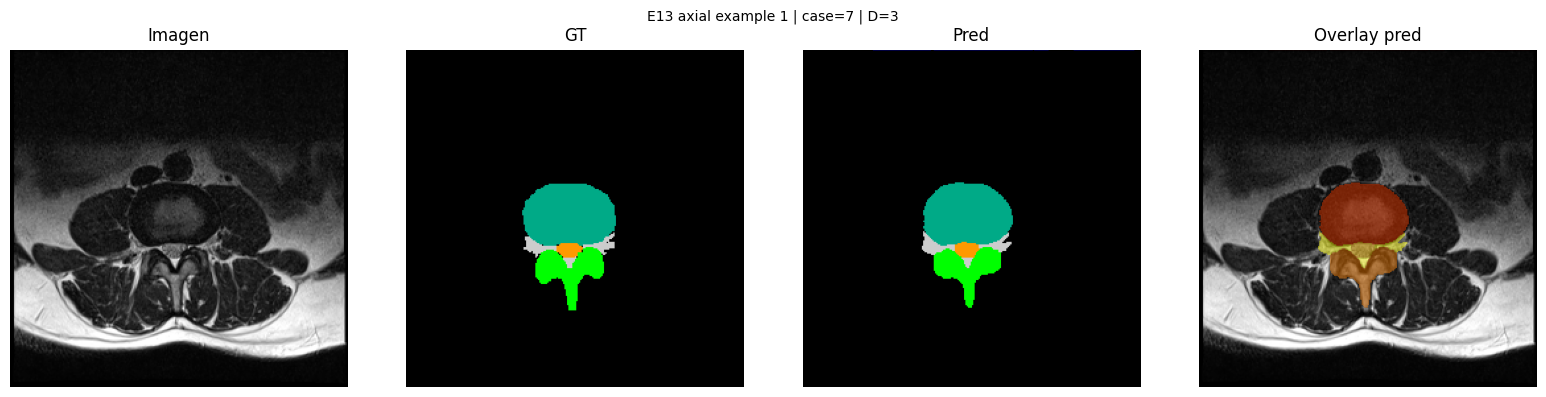

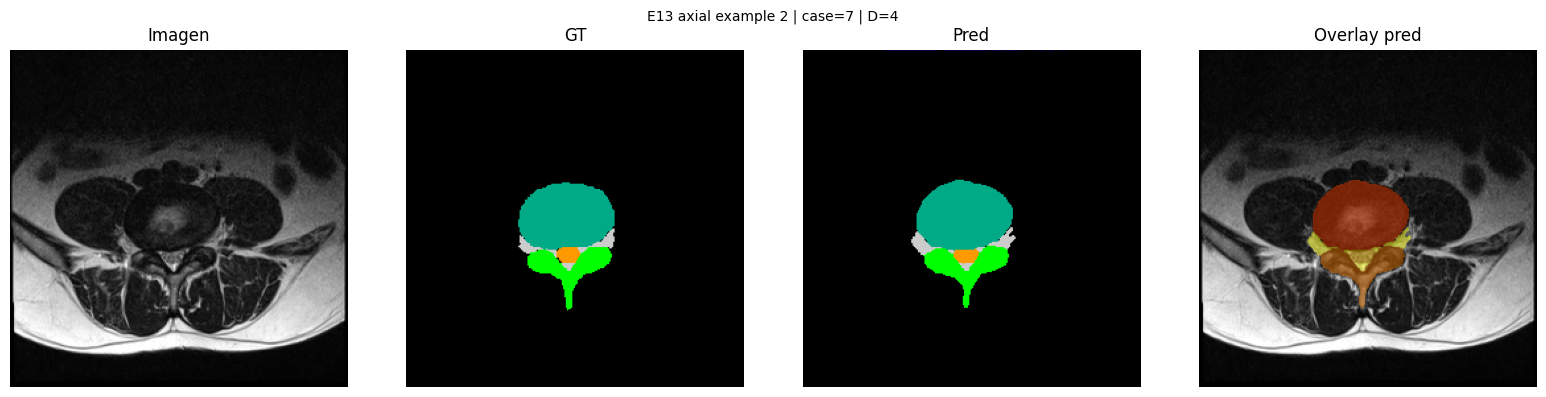

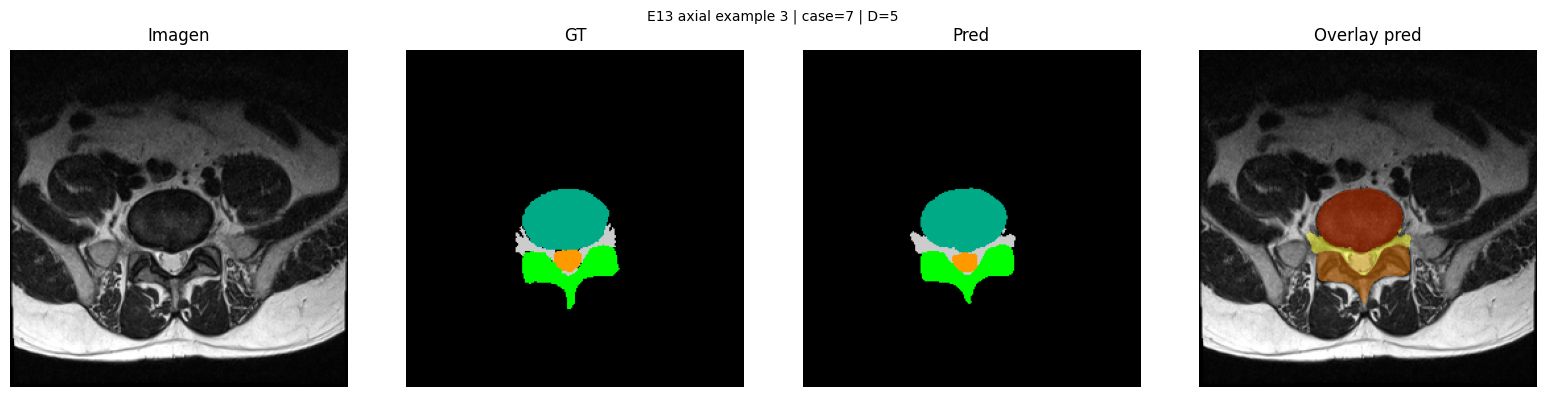

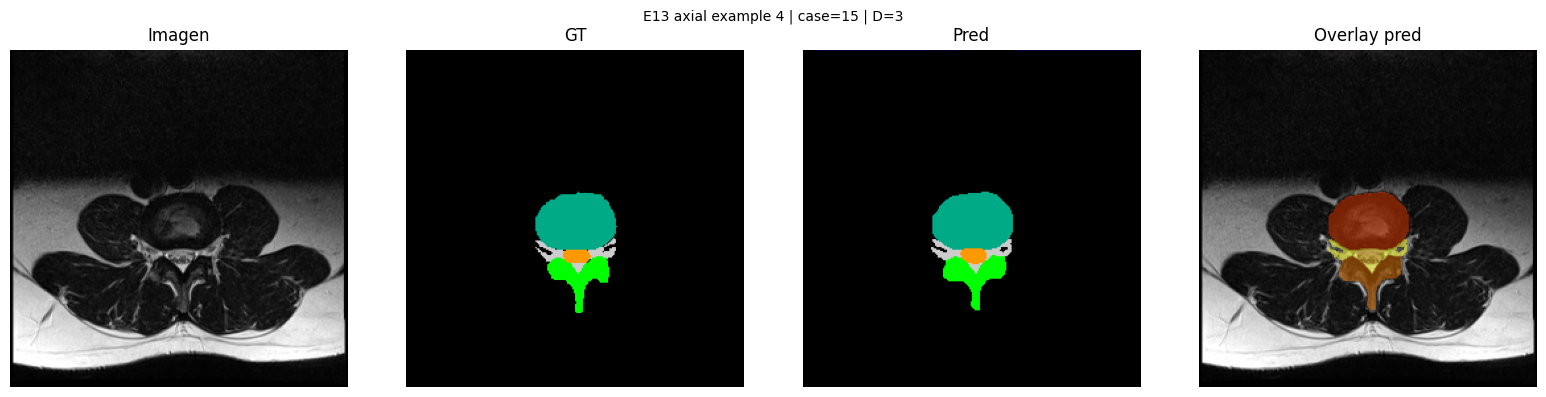

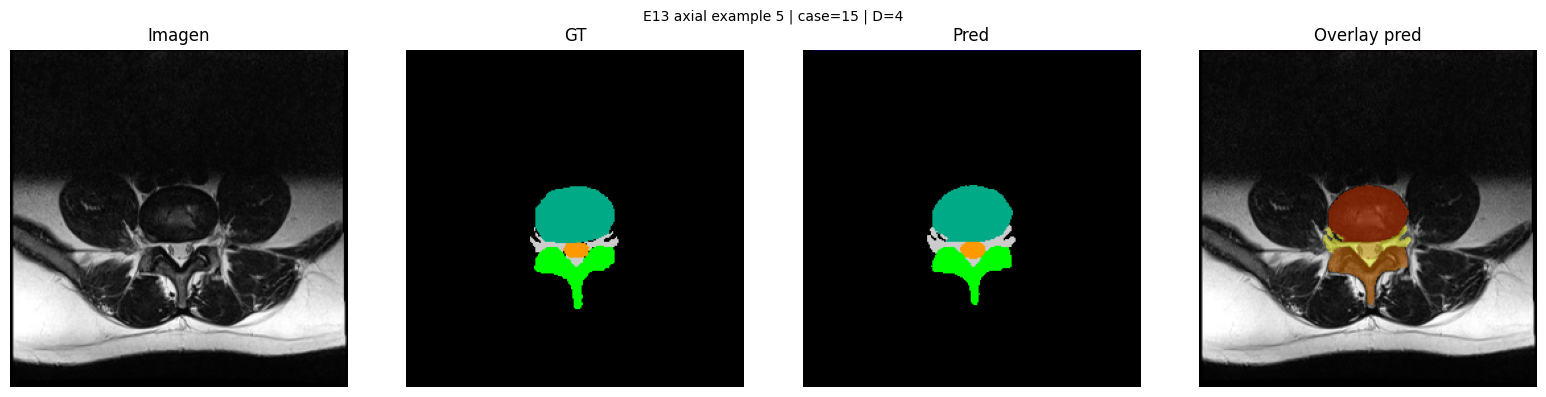

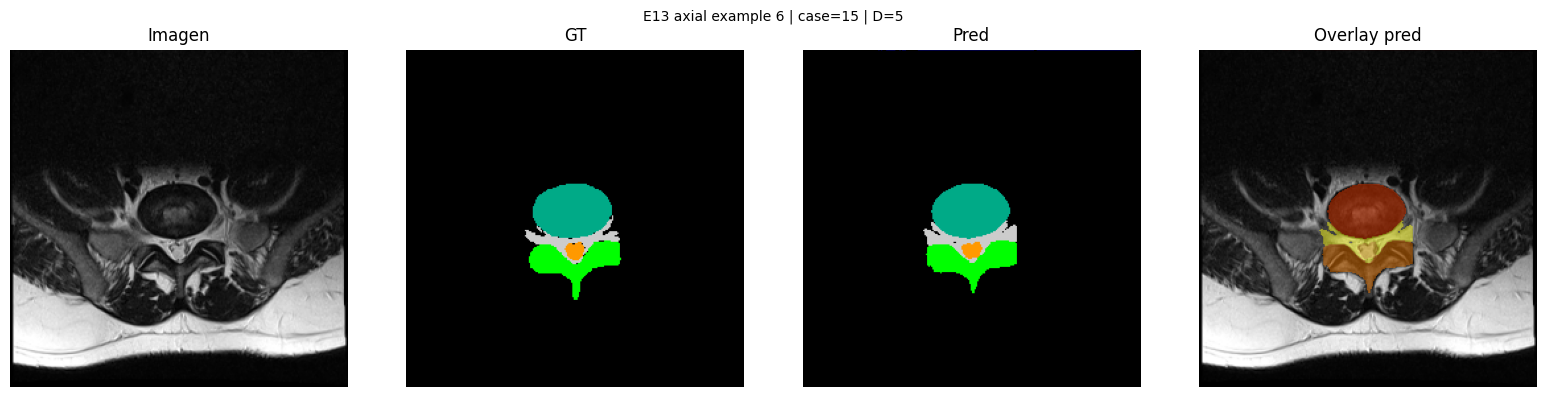

,example_id,plane,case_id_norm,disc_id,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,1,axial,7,3,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_01.png,0.067642,5,"[1, 2, 3, 4, 5]",[],0.989182,0.954711
1,2,axial,7,4,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_02.png,0.072937,12,"[1, 2, 3, 4, 5]",[muchos_componentes],0.989175,0.955937
2,3,axial,7,5,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_03.png,0.069839,2,"[1, 2, 3, 4, 5]",[],0.989071,0.968347
3,4,axial,15,3,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_04.png,0.058350,9,"[1, 2, 3, 4, 5]",[],0.989828,0.942657
4,5,axial,15,4,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_05.png,0.062454,2,"[1, 2, 3, 4, 5]",[],0.989410,0.944314
5,6,axial,15,5,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_06.png,0.063629,8,"[1, 2, 3, 4, 5]",[],0.989412,0.949532


,class_id,class_name,dice,iou,pred_pixels,gt_pixels,example_id,plane,case_id_norm,disc_id
0,0,background_250,0.995751,0.991537,61103,61034,1,axial,7,3
1,1,raw_0,0.000000,0.000000,176,0,1,axial,7,3
2,2,raw_50,0.970133,0.941998,2638,2786,1,axial,7,3
3,3,raw_100,0.914059,0.841721,1083,1186,1,axial,7,3
4,4,raw_150,0.942857,0.891892,177,173,1,axial,7,3
5,5,raw_200,0.835196,0.717026,359,357,1,axial,7,3
6,0,background_250,0.997018,0.994054,60756,60975,2,axial,7,4
7,1,raw_0,0.000000,0.000000,111,0,2,axial,7,4
8,2,raw_50,0.972658,0.946771,3023,2975,2,axial,7,4
9,3,raw_100,0.945075,0.895869,1109,1094,2,axial,7,4


In [7]:
axial_rows = []
axial_metric_rows = []

for i, (_, r) in enumerate(axial_test_df.head(6).iterrows(), 1):
    result = infer_axial_t2(r["image_file_path"])
    gt = resize_lbl(read_axial_label(r["final_label_file_path"]), IMG_SIZE)

    metrics = dice_by_class(
        result["pred"],
        gt,
        num_classes=6,
        class_names=AXIAL_CLASS_NAMES,
    )
    metrics["example_id"] = i
    metrics["plane"] = "axial"
    metrics["case_id_norm"] = str(r.get("case_id_norm", ""))
    metrics["disc_id"] = int(r.get("disc_id", -1))
    axial_metric_rows.append(metrics)

    out_path = FIGURES_ROOT / f"E13_axial_t2_example_{i:02d}.png"
    save_overlay_figure(
        result["image"],
        result["pred"],
        out_path,
        title=f"E13 axial example {i} | case={r.get('case_id_norm')} | D={r.get('disc_id')}",
        gt=gt,
    )

    axial_rows.append({
        "example_id": i,
        "plane": "axial",
        "case_id_norm": str(r.get("case_id_norm", "")),
        "disc_id": int(r.get("disc_id", -1)),
        "figure_path": str(out_path),
        **result["quality"],
    })

axial_examples_df = pd.DataFrame(axial_rows)
axial_metrics_df = pd.concat(axial_metric_rows, ignore_index=True) if axial_metric_rows else pd.DataFrame()

axial_examples_df.to_csv(E13_ROOT / "E13_axial_examples_quality.csv", index=False)
axial_metrics_df.to_csv(E13_ROOT / "E13_axial_examples_metrics_by_class.csv", index=False)

display(axial_examples_df)
display(axial_metrics_df.head(20))


## 5. Pipeline sagital SPIDER

In [8]:
SAGITTAL_CLASS_NAMES = model_registry["sagittal_spider"]["class_names"]


def read_mha_xyz(path):
    img = sitk.ReadImage(str(path))
    arr_zyx = sitk.GetArrayFromImage(img).astype(np.float32)
    arr_xyz = np.transpose(arr_zyx, (2, 1, 0))
    return arr_xyz


def extract_slice(volume, axis, idx):
    if axis == 0:
        return volume[idx, :, :]
    if axis == 1:
        return volume[:, idx, :]
    if axis == 2:
        return volume[:, :, idx]
    raise ValueError("axis debe ser 0, 1 o 2")


def group_sagittal_mask(mask_2d):
    if not sag_label_mapping:
        out = np.zeros_like(mask_2d, dtype=np.uint8)
        out[np.isin(mask_2d, list(range(1, 100)))] = 1
        out[mask_2d == 100] = 2
        out[np.isin(mask_2d, list(range(201, 300)))] = 3
        return out

    out = np.zeros_like(mask_2d, dtype=np.uint8)
    for original_value, grouped_class in sag_label_mapping.items():
        out[mask_2d == int(original_value)] = int(grouped_class)
    return out


def select_sagittal_slice(volume, axis=2, radius=3):
    n = volume.shape[axis]
    center = n // 2
    candidates = list(range(max(0, center - radius), min(n, center + radius + 1)))

    best = None
    for idx in candidates:
        sl = extract_slice(volume, axis, idx)
        img = resize_img(norm_img(sl), IMG_SIZE)
        pred, prob, conf = predict_2d(sag_model, img)
        score = float(prob[1:].sum(axis=0).mean())
        if best is None or score > best["score"]:
            best = {"idx": idx, "image": img, "pred": pred, "prob": prob, "confidence": conf, "score": score}

    return best


def candidate_case_id_from_row(row):
    if "case_id" in row and pd.notna(row["case_id"]):
        return str(row["case_id"])
    for column in ["file_name", "image_path", "source_image_path", "mask_path", "source_mask_path"]:
        if column in row and pd.notna(row[column]):
            return Path(str(row[column])).stem
    return None


def resolve_spider_path(row, kind):
    columns = (
        ["image_path", "source_image_path", "image", "img_path"]
        if kind == "image"
        else ["mask_path", "source_mask_path", "mask", "seg_path"]
    )

    direct = []
    for col in columns:
        if col in row and pd.notna(row[col]):
            direct.append(Path(str(row[col])))

    case_id = candidate_case_id_from_row(row)
    base = []
    if case_id:
        if kind == "image":
            base += [
                SPIDER_ROOT / "images" / "images" / f"{case_id}.mha",
                SPIDER_ROOT / "images" / f"{case_id}.mha",
                SPIDER_ROOT / f"{case_id}.mha",
            ]
        else:
            base += [
                SPIDER_ROOT / "masks" / "masks" / f"{case_id}.mha",
                SPIDER_ROOT / "masks" / f"{case_id}.mha",
                SPIDER_ROOT / f"{case_id}.mha",
            ]

    for p in direct + base:
        if p.exists():
            return p

    if case_id and SPIDER_ROOT.exists():
        matches = list(SPIDER_ROOT.rglob(f"{case_id}.mha"))
        if kind == "image":
            matches = [m for m in matches if "mask" not in str(m).lower()]
        else:
            matches = [m for m in matches if "mask" in str(m).lower() or "seg" in str(m).lower()]
        if matches:
            return matches[0]

    return None


def infer_sagittal_spider(image_file_path, mask_file_path=None):
    volume = read_mha_xyz(image_file_path)
    selected = select_sagittal_slice(volume, axis=sag_axis, radius=3)

    gt = None
    if mask_file_path is not None and Path(mask_file_path).exists():
        mask_volume = read_mha_xyz(mask_file_path).astype(np.int32)
        gt_raw = extract_slice(mask_volume, sag_axis, selected["idx"])
        gt = resize_lbl(group_sagittal_mask(gt_raw), IMG_SIZE)

    q = quality_flags(selected["pred"], selected["confidence"], min_fg=0.01, max_fg=0.45)

    return {
        "plane": "sagittal",
        "model_key": "sagittal_spider",
        "slice_index": int(selected["idx"]),
        "selection_score": float(selected["score"]),
        "image": selected["image"],
        "pred": selected["pred"],
        "prob": selected["prob"],
        "confidence": selected["confidence"],
        "gt": gt,
        "quality": q,
    }


if SAGITTAL_HOLDOUT_CASES.exists():
    sag_cases_df = pd.read_csv(SAGITTAL_HOLDOUT_CASES)
    print("Sagittal holdout rows:", len(sag_cases_df))
    display(sag_cases_df.head())
    print("Columns:", list(sag_cases_df.columns))
else:
    sag_cases_df = pd.DataFrame()
    print("No existe SAGITTAL_HOLDOUT_CASES. Se saltea demo sagital.")


Sagittal holdout rows: 40


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,mask_origin_xyz,same_origin,image_direction,mask_direction,same_direction,image_dtype,mask_dtype,image_min,image_max,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels,inferred_modality,source_image_path,source_mask_path
0,101_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha,"(298, 320, 17)","(298, 320, 17)",True,"(4.788765599257572, 0.812500000003979, 0.8762882583044416)","(4.788765599257572, 0.812500000003979, 0.8762882583044416)",True,"(-67.28904018297013, -124.77837801043, -103.82282952743962)","(-67.28904018297013, -124.77837801043, -103.82282952743962)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,286.182632,-1000.0,-1000.0,-96.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204, 205, 206]","{""0"": 1485954, ""1"": 17797, ""2"": 19492, ""3"": 18445, ""4"": 16664, ""5"": 15505, ""6"": 12154, ""100"": 14233, ""201"": 4400, ""202"": 4545, ""203"": 3580, ""204"": 4119, ""205"": 2407, ""206"": 1825}",135166,t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha
1,116_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha,"(320, 320, 15)","(320, 320, 15)",True,"(4.799999918256501, 1.0625, 1.0625)","(4.799999918256501, 1.0625, 1.0625)",True,"(-1491.7994993754837, -168.68538045966, -466.0026564307672)","(-1491.7994993754837, -168.68538045966, -466.0026564307672)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,136.206472,-1000.0,-1000.0,-420.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 204, 205, 206, 207]","{""0"": 1476528, ""1"": 6713, ""2"": 7396, ""3"": 7127, ""4"": 7014, ""5"": 6161, ""6"": 5123, ""7"": 4281, ""100"": 10139, ""201"": 802, ""202"": 1002, ""203"": 1051, ""204"": 739, ""205"": 838, ""206"": 6...",59472,t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha
2,117_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha,"(448, 448, 24)","(448, 448, 24)",True,"(3.299954757096529, 0.625, 0.6252388405906117)","(3.299954757096529, 0.625, 0.6252388405906117)",True,"(-27.539267850991315, -96.346813201904, -126.06298272872613)","(-27.539267850991315, -96.346813201904, -126.06298272872613)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,527.163481,-1000.0,-1000.0,316.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204, 205, 206]","{""0"": 4632138, ""1"": 27188, ""2"": 27381, ""3"": 27832, ""4"": 23176, ""5"": 19347, ""6"": 15219, ""100"": 22647, ""201"": 5302, ""202"": 4360, ""203"": 3294, ""204"": 2851, ""205"": 3111, ""206"": 3050}",184758,t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha
3,12_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/12_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/12_t1.mha,"(320, 320, 15)","(320, 320, 15)",True,"(4.800000123092809, 0.875, 0.875)","(4.800000123092809, 0.875, 0.875)",True,"(-1512.6634184645181, -60.460044861525, -109.24127259665528)","(-1512.6634184645181, -60.460044861525, -109.24127259665528)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,-54.331339,-1000.0,-1000.0,-861.0,30

Columns: ['case_id', 'image_path', 'mask_path', 'image_shape_zyx', 'mask_shape_zyx', 'same_shape', 'image_spacing_xyz', 'mask_spacing_xyz', 'same_spacing', 'image_origin_xyz', 'mask_origin_xyz', 'same_origin', 'image_direction', 'mask_direction', 'same_direction', 'image_dtype', 'mask_dtype', 'image_min', 'image_max', 'image_mean', 'image_p01', 'image_p05', 'image_p50', 'image_p95', 'image_p99', 'mask_unique_labels', 'mask_label_voxel_counts', 'mask_nonzero_voxels', 'inferred_modality', 'source_image_path', 'source_mask_path']


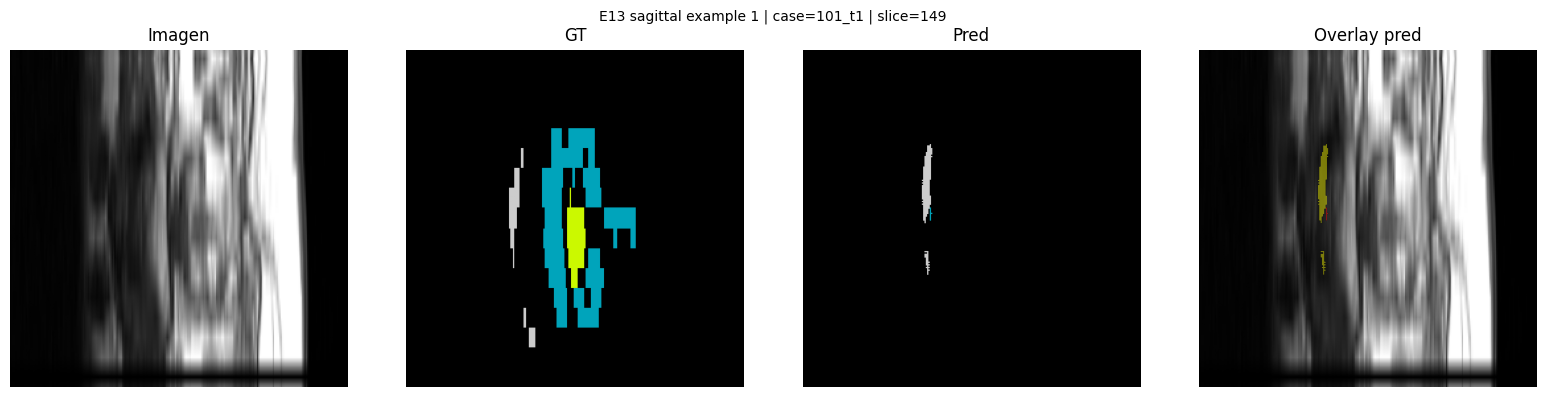

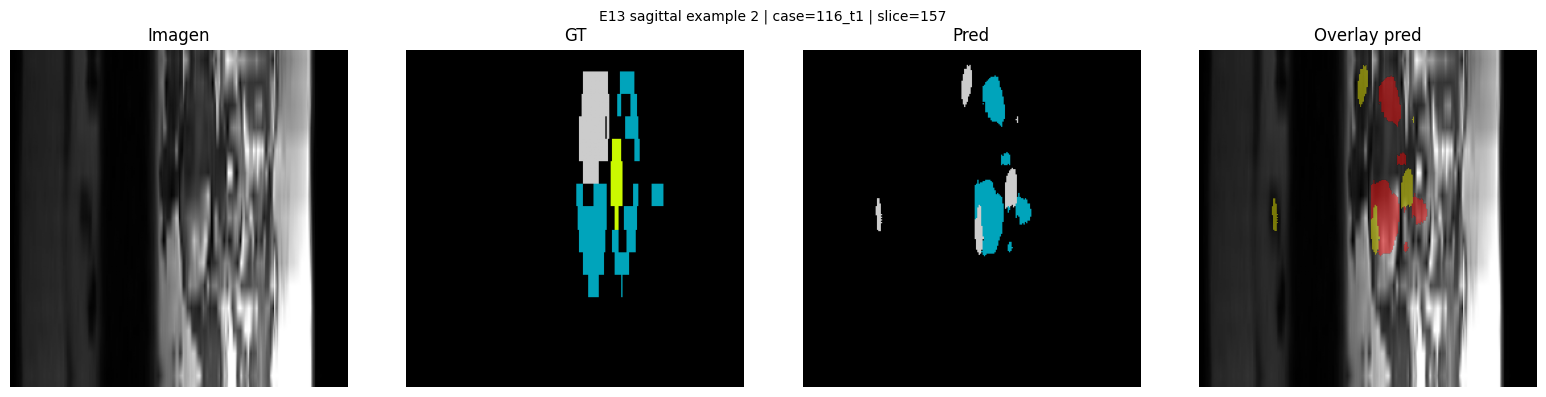

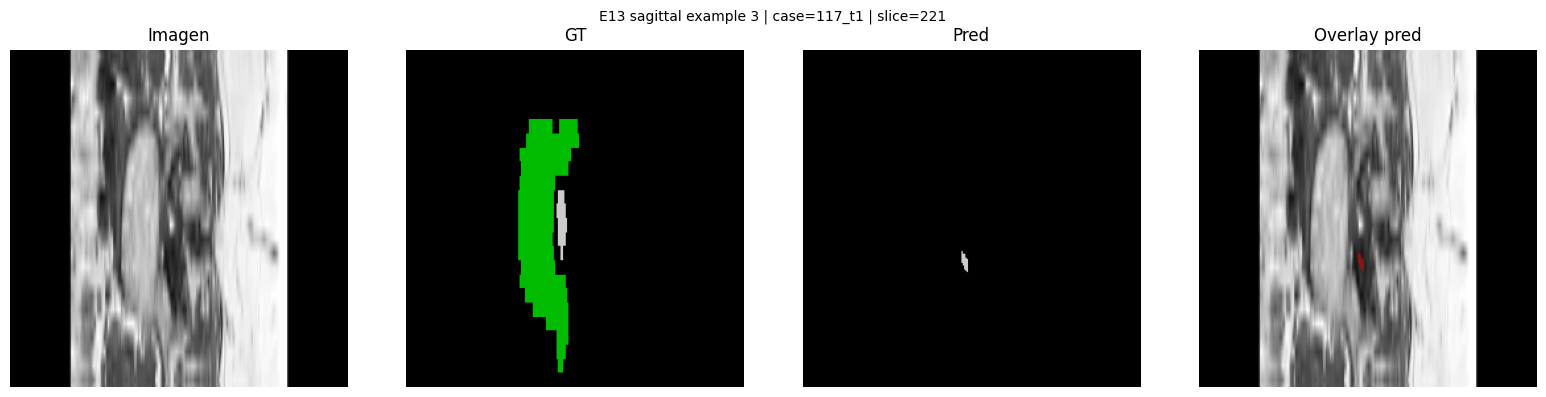

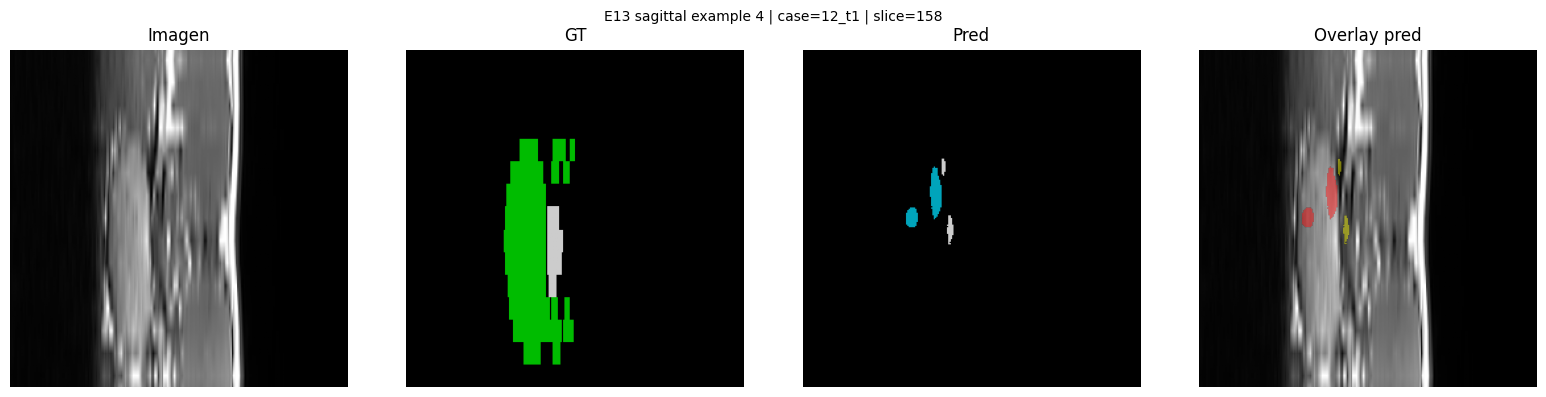

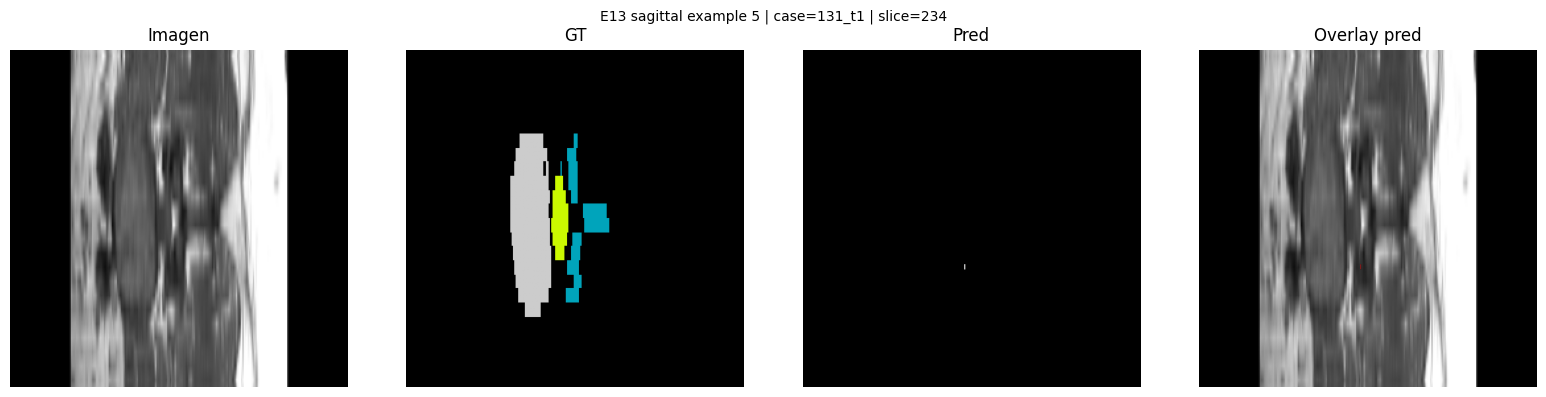

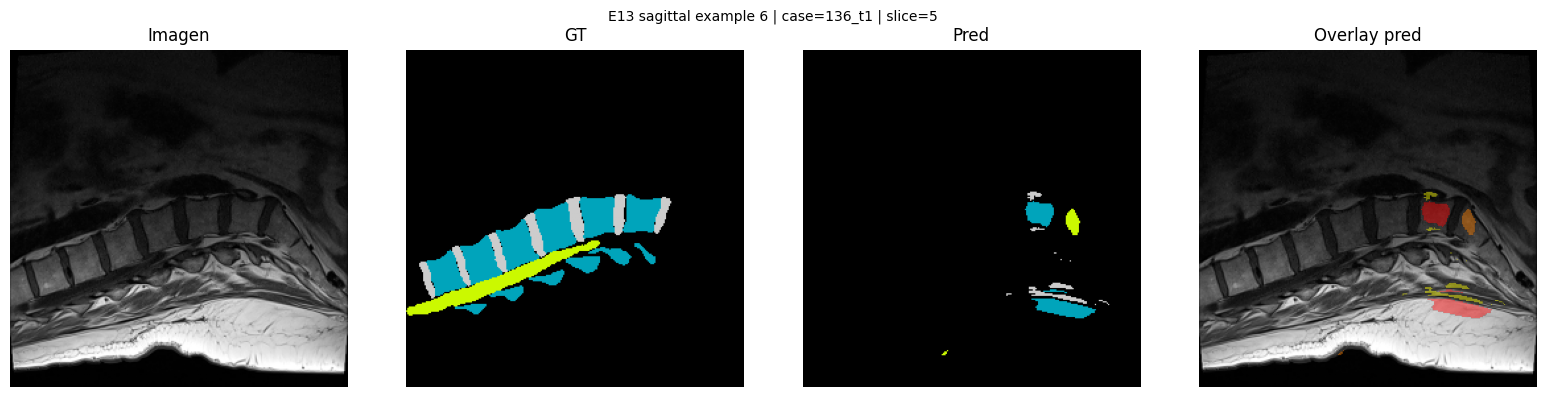

,example_id,plane,case_id,slice_index,selection_score,image_path,mask_path,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,1,sagittal,101_t1,149,0.071104,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_example_01.png,0.005249,2,"[1, 3]",[foreground_muy_bajo],0.931061,0.672298
1,2,sagittal,116_t1,157,0.108043,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_example_02.png,0.034637,9,"[1, 3]",[],0.906974,0.661436
2,3,sagittal,117_t1,221,0.054797,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_example_03.png,0.000763,1,[3],[foreground_muy_bajo],0.945373,0.570714
3,4,sagittal,12_t1,158,0.070895,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/12_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/12_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_example_04.png,0.007263,4,"[1, 3]",[foreground_muy_bajo],0.931315,0.592724
4,5,sagittal,131_t1,234,0.056581,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/131_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/131_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_example_05.png,0.000061,1,[3],[foreground_muy_bajo],0.943421,0.481272
5,6,sagittal,136_t1,5,0.091479,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/136_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/136_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_example_06.png,0.018127,19,"[1, 2, 3]",[muchos_componentes],0.916456,0.671983


,class_id,class_name,dice,iou,pred_pixels,gt_pixels,example_id,plane,case_id
0,0,background,0.954827,0.913559,65192,60215,1,sagittal,101_t1
1,1,vertebra_group,0.000000,0.000000,11,4162,1,sagittal,101_t1
2,2,canal,0.000000,0.000000,0,688,1,sagittal,101_t1
3,3,disc_group,0.000000,0.000000,333,471,1,sagittal,101_t1
4,0,background,0.969497,0.940800,63266,60656,2,sagittal,116_t1
5,1,vertebra_group,0.375857,0.231419,1605,2769,2,sagittal,116_t1
6,2,canal,0.000000,0.000000,0,479,2,sagittal,116_t1
7,3,disc_group,0.000000,0.000000,665,1632,2,sagittal,116_t1
8,0,background,0.957835,0.919083,65486,60283,3,sagittal,117_t1
9,1,vertebra_group,0.000000,0.000000,0,4967,3,sagittal,117_t1


In [9]:
sag_rows = []
sag_metric_rows = []

if len(sag_cases_df) > 0:
    for i, (_, r) in enumerate(sag_cases_df.head(6).iterrows(), 1):
        img_path = resolve_spider_path(r, "image")
        mask_path = resolve_spider_path(r, "mask")

        if img_path is None:
            print("No se pudo resolver imagen para fila", i)
            continue

        result = infer_sagittal_spider(img_path, mask_path)

        if result["gt"] is not None:
            metrics = dice_by_class(
                result["pred"],
                result["gt"],
                num_classes=sag_num_classes,
                class_names=SAGITTAL_CLASS_NAMES,
            )
            metrics["example_id"] = i
            metrics["plane"] = "sagittal"
            metrics["case_id"] = candidate_case_id_from_row(r)
            sag_metric_rows.append(metrics)

        out_path = FIGURES_ROOT / f"E13_sagittal_example_{i:02d}.png"
        save_overlay_figure(
            result["image"],
            result["pred"],
            out_path,
            title=f"E13 sagittal example {i} | case={candidate_case_id_from_row(r)} | slice={result['slice_index']}",
            gt=result["gt"],
        )

        sag_rows.append({
            "example_id": i,
            "plane": "sagittal",
            "case_id": candidate_case_id_from_row(r),
            "slice_index": result["slice_index"],
            "selection_score": result["selection_score"],
            "image_path": str(img_path),
            "mask_path": str(mask_path) if mask_path else None,
            "figure_path": str(out_path),
            **result["quality"],
        })

sag_examples_df = pd.DataFrame(sag_rows)
sag_metrics_df = pd.concat(sag_metric_rows, ignore_index=True) if sag_metric_rows else pd.DataFrame()

sag_examples_df.to_csv(E13_ROOT / "E13_sagittal_examples_quality.csv", index=False)
sag_metrics_df.to_csv(E13_ROOT / "E13_sagittal_examples_metrics_by_class.csv", index=False)

display(sag_examples_df)
display(sag_metrics_df.head(20))


## 6. Reporte final E13

In [10]:
def df_summary(df, name):
    return {
        "name": name,
        "rows": int(len(df)),
        "columns": list(df.columns) if len(df.columns) else [],
    }


report = {
    "notebook": "21_E13_multiplanar_inference_pipeline",
    "goal": "common inference pipeline for sagittal SPIDER and axial T2 models",
    "models": {
        "sagittal_spider": {
            "path": str(SAGITTAL_MODEL_PATH),
            "num_classes": sag_num_classes,
            "target_size": list(sag_target_size),
            "axis": sag_axis,
            "slice_strategy": sag_slice_strategy,
        },
        "axial_t2_alkafri": {
            "path": str(AXIAL_MODEL_PATH),
            "num_classes": 6,
            "target_size": [IMG_SIZE, IMG_SIZE],
        },
    },
    "outputs": {
        "axial_quality_csv": str(E13_ROOT / "E13_axial_examples_quality.csv"),
        "axial_metrics_csv": str(E13_ROOT / "E13_axial_examples_metrics_by_class.csv"),
        "sagittal_quality_csv": str(E13_ROOT / "E13_sagittal_examples_quality.csv"),
        "sagittal_metrics_csv": str(E13_ROOT / "E13_sagittal_examples_metrics_by_class.csv"),
    },
    "summaries": [
        df_summary(axial_examples_df, "axial_examples_quality"),
        df_summary(axial_metrics_df, "axial_examples_metrics_by_class"),
        df_summary(sag_examples_df, "sagittal_examples_quality"),
        df_summary(sag_metrics_df, "sagittal_examples_metrics_by_class"),
    ],
    "decision": "common_multiplanar_inference_pipeline_ready_for_agent_prototype",
}

report_path = E13_ROOT / "E13_multiplanar_pipeline_report.json"
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

md = f"""# E13 - Pipeline común de inferencia multiplanar

## Objetivo

Este notebook implementa un pipeline común para ejecutar inferencia con los dos modelos finales del proyecto:

- Modelo sagital SPIDER consolidado en E12.
- Modelo axial T2 Al-Kafri/Sudirman entrenado en E10.

## Resultado

Se generaron funciones comunes para:

- cargar modelos,
- preprocesar imágenes,
- ejecutar inferencia 2D,
- generar máscaras,
- generar overlays,
- calcular métricas por clase cuando existe ground truth,
- calcular quality flags.

## Modelos usados

- Sagital: `{SAGITTAL_MODEL_PATH}`
- Axial T2: `{AXIAL_MODEL_PATH}`

## Salidas

- `{E13_ROOT / "E13_axial_examples_quality.csv"}`
- `{E13_ROOT / "E13_axial_examples_metrics_by_class.csv"}`
- `{E13_ROOT / "E13_sagittal_examples_quality.csv"}`
- `{E13_ROOT / "E13_sagittal_examples_metrics_by_class.csv"}`

## Decisión

El pipeline común queda listo para avanzar a E14, donde se implementará el prototipo de agente/orquestador IA.
"""

md_path = DOCS_ROOT / "E13_multiplanar_inference_pipeline_conclusion.md"
md_path.write_text(md, encoding="utf-8")

print("Reporte JSON:", report_path)
print("Reporte Markdown:", md_path)
print(json.dumps(report, indent=2, ensure_ascii=False))


Reporte JSON: /content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_multiplanar_pipeline_report.json
Reporte Markdown: /content/drive/MyDrive/PFI_MVP/docs/E13_multiplanar_inference_pipeline_conclusion.md
{
  "notebook": "21_E13_multiplanar_inference_pipeline",
  "goal": "common inference pipeline for sagittal SPIDER and axial T2 models",
  "models": {
    "sagittal_spider": {
      "path": "/content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt",
      "num_classes": 4,
      "target_size": [
        256,
        256
      ],
      "axis": 2,
      "slice_strategy": "center_window_best_prediction"
    },
    "axial_t2_alkafri": {
      "path": "/content/drive/MyDrive/PFI_MVP/models/E10_axial_t2_final_training_clean_best.pt",
      "num_classes": 6,
      "target_size": [
        256,
        256
      ]
    }
  },
  "outputs": {
    "axial_quality_csv": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_axial_exam

In [23]:
# FIX: funciones auxiliares faltantes para E13 patch

import numpy as np
import pandas as pd
from scipy import ndimage


def compute_quality_flags(pred, conf=None):
    """
    Quality flags simples para una máscara predicha 2D.
    """
    pred = np.asarray(pred)
    fg = pred > 0

    foreground_ratio = float(fg.mean())

    if fg.any():
        labeled, n_components = ndimage.label(fg)
    else:
        n_components = 0

    present_classes = sorted([int(c) for c in np.unique(pred) if int(c) != 0])

    flags = []

    if foreground_ratio < 0.001:
        flags.append("foreground_muy_bajo")

    if foreground_ratio > 0.40:
        flags.append("foreground_muy_alto")

    if n_components > 10:
        flags.append("muchos_componentes")

    mean_confidence = None
    mean_fg_confidence = None

    if conf is not None:
        conf = np.asarray(conf)
        mean_confidence = float(np.mean(conf))

        if fg.any():
            mean_fg_confidence = float(np.mean(conf[fg]))
        else:
            mean_fg_confidence = None

        if mean_confidence < 0.70:
            flags.append("baja_confianza_media")

        if mean_fg_confidence is not None and mean_fg_confidence < 0.70:
            flags.append("baja_confianza_foreground")

    return {
        "foreground_ratio": foreground_ratio,
        "n_components": int(n_components),
        "present_classes": present_classes,
        "flags": flags,
        "mean_confidence": mean_confidence,
        "mean_fg_confidence": mean_fg_confidence,
    }


def metrics_by_class(pred, gt, class_names):
    """
    Dice e IoU por clase para predicción y ground truth 2D.
    """
    pred = np.asarray(pred).astype(np.uint8)
    gt = np.asarray(gt).astype(np.uint8)

    rows = []

    for class_id, class_name in class_names.items():
        p = pred == int(class_id)
        g = gt == int(class_id)

        inter = int(np.logical_and(p, g).sum())
        pred_pixels = int(p.sum())
        gt_pixels = int(g.sum())

        denom_dice = pred_pixels + gt_pixels
        union = pred_pixels + gt_pixels - inter

        dice = float((2 * inter) / denom_dice) if denom_dice > 0 else 1.0
        iou = float(inter / union) if union > 0 else 1.0

        rows.append(
            {
                "class_id": int(class_id),
                "class_name": class_name,
                "dice": dice,
                "iou": iou,
                "pred_pixels": pred_pixels,
                "gt_pixels": gt_pixels,
            }
        )

    return rows


print("Funciones compute_quality_flags y metrics_by_class listas.")

Funciones compute_quality_flags y metrics_by_class listas.


In [24]:
# FIX: reconstruir sagittal_holdout_df para el patch E13 sagital

from pathlib import Path
import pandas as pd

PFI_ROOT = Path("/content/drive/MyDrive/PFI_MVP")
HOLDOUT_ROOT = PFI_ROOT / "results" / "E5_multiclase_holdout"

HOLDOUT_SELECTED_CASES_PATH = HOLDOUT_ROOT / "E5_multiclass_holdout_selected_cases.csv"

print("HOLDOUT_SELECTED_CASES_PATH:", HOLDOUT_SELECTED_CASES_PATH)
print("Existe:", HOLDOUT_SELECTED_CASES_PATH.exists())

assert HOLDOUT_SELECTED_CASES_PATH.exists(), f"No encontré: {HOLDOUT_SELECTED_CASES_PATH}"

sagittal_holdout_df = pd.read_csv(HOLDOUT_SELECTED_CASES_PATH)

# Normalizar paths por seguridad
if "image_path" not in sagittal_holdout_df.columns and "source_image_path" in sagittal_holdout_df.columns:
    sagittal_holdout_df["image_path"] = sagittal_holdout_df["source_image_path"]

if "mask_path" not in sagittal_holdout_df.columns and "source_mask_path" in sagittal_holdout_df.columns:
    sagittal_holdout_df["mask_path"] = sagittal_holdout_df["source_mask_path"]

required_cols = ["case_id", "image_path", "mask_path"]
missing = [c for c in required_cols if c not in sagittal_holdout_df.columns]
assert not missing, f"Faltan columnas necesarias: {missing}"

print("Sagittal holdout rows:", len(sagittal_holdout_df))
print("Columns:", list(sagittal_holdout_df.columns))

display(sagittal_holdout_df[["case_id", "image_path", "mask_path"]].head(6))

HOLDOUT_SELECTED_CASES_PATH: /content/drive/MyDrive/PFI_MVP/results/E5_multiclase_holdout/E5_multiclass_holdout_selected_cases.csv
Existe: True
Sagittal holdout rows: 40
Columns: ['case_id', 'image_path', 'mask_path', 'image_shape_zyx', 'mask_shape_zyx', 'same_shape', 'image_spacing_xyz', 'mask_spacing_xyz', 'same_spacing', 'image_origin_xyz', 'mask_origin_xyz', 'same_origin', 'image_direction', 'mask_direction', 'same_direction', 'image_dtype', 'mask_dtype', 'image_min', 'image_max', 'image_mean', 'image_p01', 'image_p05', 'image_p50', 'image_p95', 'image_p99', 'mask_unique_labels', 'mask_label_voxel_counts', 'mask_nonzero_voxels', 'inferred_modality', 'source_image_path', 'source_mask_path']


,case_id,image_path,mask_path
0,101_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha
1,116_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha
2,117_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha
3,12_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/12_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/12_t1.mha
4,131_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/131_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/131_t1.mha
5,136_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/136_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/136_t1.mha


In [25]:
# E13 PATCH v2 - Sagital axis=2 correcto

import SimpleITK as sitk
from skimage.transform import resize
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

E13_PATCH_ROOT = E13_ROOT / "sagittal_axis2_patch"
E13_PATCH_ROOT.mkdir(parents=True, exist_ok=True)

SAGITTAL_PATCH_FIGURES_ROOT = FIGURES_ROOT / "E13_sagittal_axis2_patch"
SAGITTAL_PATCH_FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

print("Patch root:", E13_PATCH_ROOT)
print("Patch figures:", SAGITTAL_PATCH_FIGURES_ROOT)


def extract_slice_axis2(arr, idx):
    """
    SPIDER/SimpleITK devuelve array en formato z,y,x.
    Para sagittal_axis=2, el corte correcto es arr[:, :, idx].
    """
    assert arr.ndim == 3, f"Se esperaba volumen 3D, shape={arr.shape}"
    idx = int(idx)
    assert 0 <= idx < arr.shape[2], f"idx fuera de rango para axis=2: idx={idx}, shape={arr.shape}"
    return arr[:, :, idx]


def group_spider_mask(mask2d, mapping):
    """
    Agrupa labels SPIDER según mapping del checkpoint E5.
    """
    out = np.zeros_like(mask2d, dtype=np.uint8)
    for raw_label, group_id in mapping.items():
        out[mask2d == int(raw_label)] = int(group_id)
    return out


def normalize_img_2d(x):
    x = x.astype(np.float32)
    p1, p99 = np.percentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x, dtype=np.float32)
    return ((np.clip(x, p1, p99) - p1) / (p99 - p1 + 1e-8)).astype(np.float32)


def resize_img_2d(x, target_size=(256, 256)):
    return resize(
        x,
        target_size,
        order=1,
        preserve_range=True,
        anti_aliasing=True,
    ).astype(np.float32)


def resize_lbl_2d(y, target_size=(256, 256)):
    return resize(
        y.astype(np.float32),
        target_size,
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    ).astype(np.uint8)


def select_best_sagittal_idx_axis2(mask_arr, mapping, min_fg_ratio=0.001):
    """
    Selecciona el corte sagital con mayor foreground agrupado.
    El índice resultante siempre pertenece a axis=2.
    """
    scores = []

    for idx in range(mask_arr.shape[2]):
        m2d = extract_slice_axis2(mask_arr, idx)
        g2d = group_spider_mask(m2d, mapping)
        fg_ratio = float((g2d > 0).mean())
        scores.append((idx, fg_ratio))

    scores_df = pd.DataFrame(scores, columns=["slice_idx_axis2", "gt_fg_ratio"])
    best_row = scores_df.sort_values("gt_fg_ratio", ascending=False).iloc[0]

    return int(best_row["slice_idx_axis2"]), float(best_row["gt_fg_ratio"]), scores_df


@torch.no_grad()
def infer_sagittal_axis2_fixed(image_path, mask_path, model, mapping, device):
    """
    Inferencia sagital corregida:
    - lee volumen z,y,x
    - selecciona slice axis=2
    - predice sobre ese corte
    - devuelve imagen, GT agrupado y predicción
    """
    img_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(image_path)))
    mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))

    assert img_arr.shape == mask_arr.shape, f"Shape mismatch: {img_arr.shape} vs {mask_arr.shape}"

    idx, gt_fg_ratio_original, scores_df = select_best_sagittal_idx_axis2(mask_arr, mapping)

    img2d = extract_slice_axis2(img_arr, idx)
    mask2d_raw = extract_slice_axis2(mask_arr, idx)
    gt_grouped = group_spider_mask(mask2d_raw, mapping)

    img_norm = normalize_img_2d(img2d)
    img_resized = resize_img_2d(img_norm, tuple(SAGITTAL_TARGET_SIZE))
    gt_resized = resize_lbl_2d(gt_grouped, tuple(SAGITTAL_TARGET_SIZE))

    x = torch.from_numpy(img_resized[None, None]).float().to(device)

    logits = sagittal_model(x)
    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred = probs.argmax(axis=0).astype(np.uint8)
    conf = probs.max(axis=0).astype(np.float32)

    return {
        "image": img_resized,
        "gt": gt_resized,
        "pred": pred,
        "confidence": conf,
        "slice_idx_axis2": idx,
        "gt_fg_ratio_original": gt_fg_ratio_original,
        "scores_df": scores_df,
        "original_shape_zyx": img_arr.shape,
    }

Patch root: /content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/sagittal_axis2_patch
Patch figures: /content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch


In [26]:
# FIX variables faltantes para E13 patch sagital

import torch
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAGITTAL_MODEL_PATH = Path("/content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt")

sagittal_checkpoint = torch.load(SAGITTAL_MODEL_PATH, map_location=device)

SAGITTAL_NUM_CLASSES = int(sagittal_checkpoint.get("num_classes", 4))
SAGITTAL_TARGET_SIZE = tuple(sagittal_checkpoint.get("target_size", (256, 256)))
SAGITTAL_AXIS = int(sagittal_checkpoint.get("sagittal_axis", 2))

SAGITTAL_CLASS_NAMES = {
    0: "background",
    1: "vertebra_group",
    2: "canal",
    3: "disc_group",
}

SAGITTAL_LABEL_GROUP_MAPPING = {
    int(k): int(v)
    for k, v in sagittal_checkpoint.get("label_group_mapping", {}).items()
}

print("device:", device)
print("SAGITTAL_MODEL_PATH:", SAGITTAL_MODEL_PATH)
print("SAGITTAL_NUM_CLASSES:", SAGITTAL_NUM_CLASSES)
print("SAGITTAL_TARGET_SIZE:", SAGITTAL_TARGET_SIZE)
print("SAGITTAL_AXIS:", SAGITTAL_AXIS)
print("Mapping:", SAGITTAL_LABEL_GROUP_MAPPING)

device: cpu
SAGITTAL_MODEL_PATH: /content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt
SAGITTAL_NUM_CLASSES: 4
SAGITTAL_TARGET_SIZE: (256, 256)
SAGITTAL_AXIS: 2
Mapping: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 100: 2, 201: 3, 202: 3, 203: 3, 204: 3, 205: 3, 206: 3, 207: 3, 208: 3, 209: 3}


In [27]:
# Reconstruir modelo sagital si no existe sagittal_model

import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleUNet2DMulticlass(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, base_channels=16):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)
        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)
        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


sagittal_model = SimpleUNet2DMulticlass(
    in_channels=1,
    num_classes=SAGITTAL_NUM_CLASSES,
    base_channels=int(sagittal_checkpoint.get("base_channels", 16)),
).to(device)

sagittal_model.load_state_dict(sagittal_checkpoint["model_state_dict"])
sagittal_model.eval()

print("sagittal_model reconstruido OK")

sagittal_model reconstruido OK


Mapping SPIDER agrupado: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 100: 2, 201: 3, 202: 3, 203: 3, 204: 3, 205: 3, 206: 3, 207: 3, 208: 3, 209: 3}


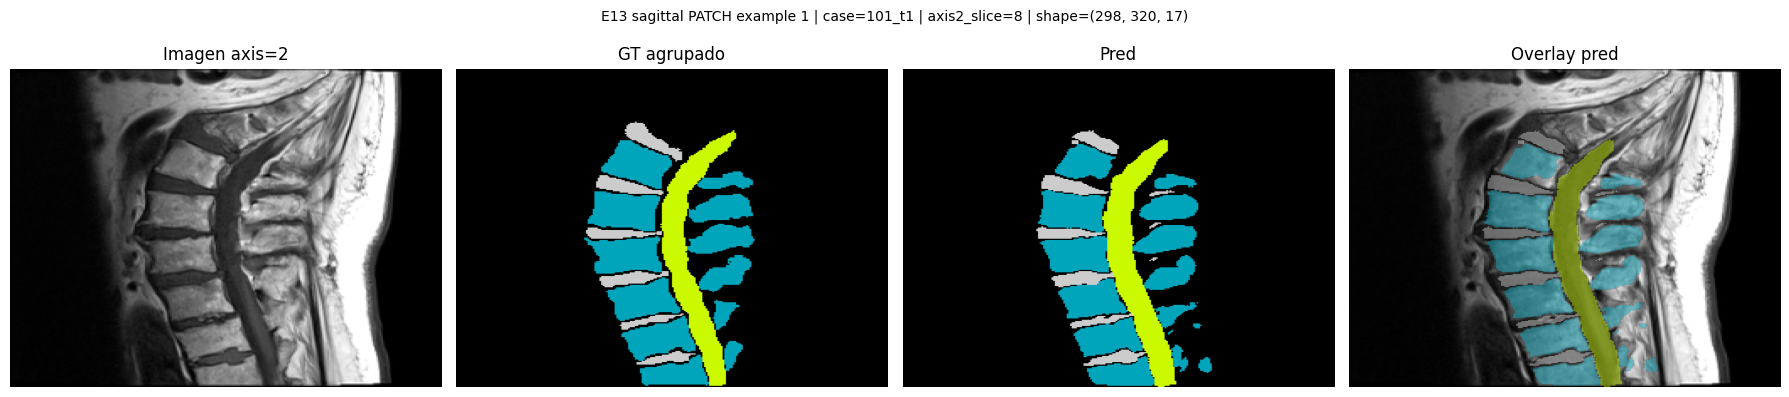

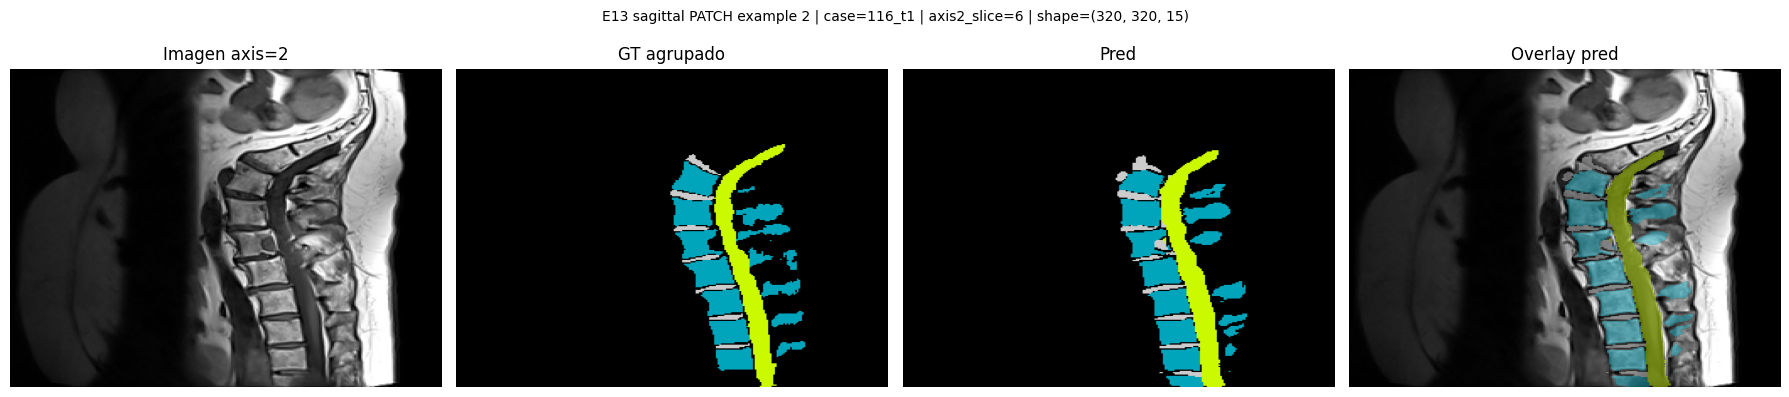

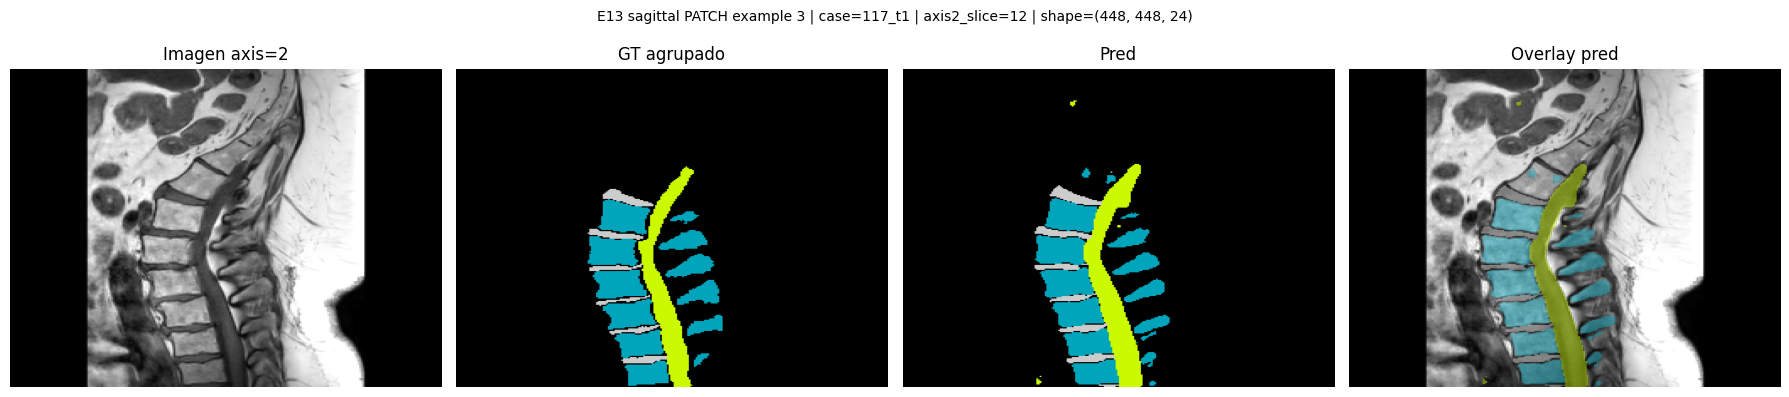

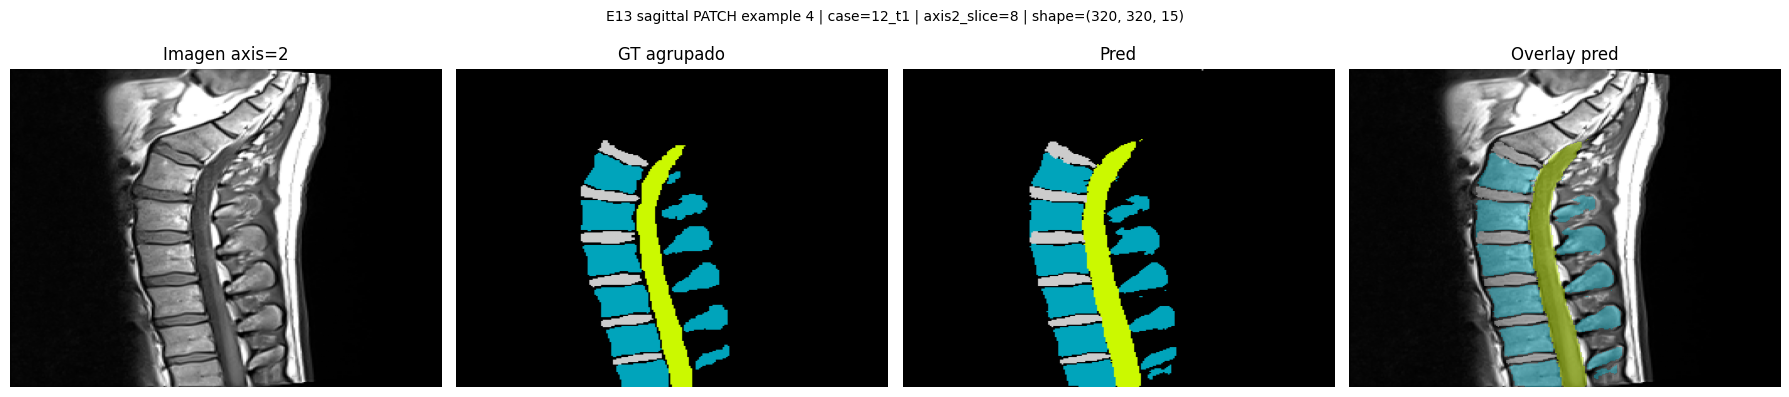

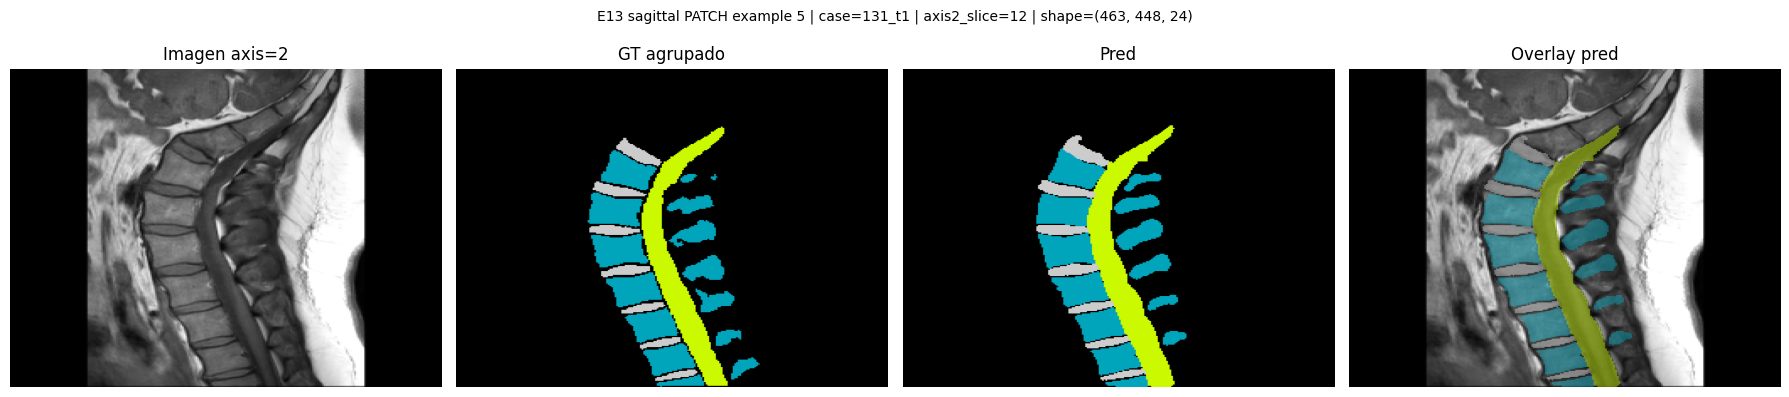

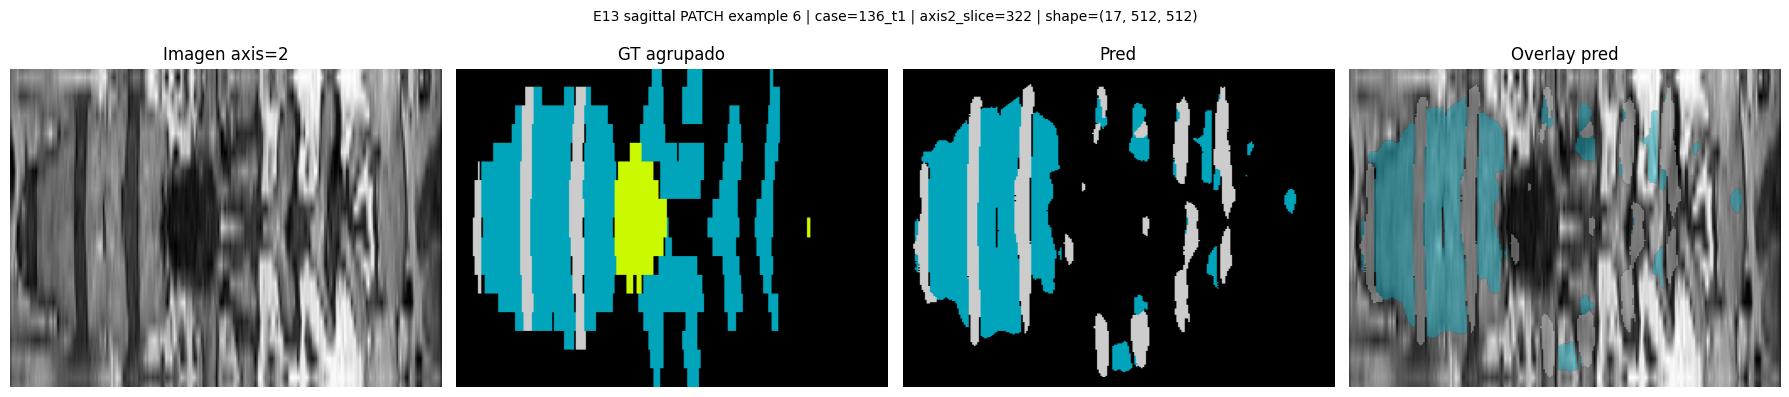

,example_id,plane,case_id,slice_idx_axis2,original_shape_zyx,gt_fg_ratio_original,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,1,sagittal,101_t1,8,"(298, 320, 17)",0.188286,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch/E13_sagittal_axis2_patch_example_01.png,0.181458,13,"[1, 2, 3]",[muchos_componentes],0.907111,0.843732
1,2,sagittal,116_t1,6,"(320, 320, 15)",0.099248,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch/E13_sagittal_axis2_patch_example_02.png,0.104843,12,"[1, 2, 3]",[muchos_componentes],0.916900,0.847062
2,3,sagittal,117_t1,12,"(448, 448, 24)",0.105095,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch/E13_sagittal_axis2_patch_example_03.png,0.112305,15,"[1, 2, 3]",[muchos_componentes],0.926663,0.873984
3,4,sagittal,12_t1,8,"(320, 320, 15)",0.142334,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch/E13_sagittal_axis2_patch_example_04.png,0.152420,11,"[1, 2, 3]",[muchos_componentes],0.922323,0.888282
4,5,sagittal,131_t1,12,"(463, 448, 24)",0.139666,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch/E13_sagittal_axis2_patch_example_05.png,0.146667,7,"[1, 2, 3]",[],0.922671,0.861709
5,6,sagittal,136_t1,322,"(17, 512, 512)",0.375804,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch/E13_sagittal_axis2_patch_example_06.png,0.260376,20,"[1, 3]",[muchos_componentes],0.858114,0.789306


,class_id,class_name,dice,iou,pred_pixels,gt_pixels,example_id,plane,case_id,slice_idx_axis2
0,0,background,0.976744,0.954545,53644,53209,1,sagittal,101_t1,8
1,1,vertebra_group,0.903492,0.823972,7306,7957,1,sagittal,101_t1,8
2,2,canal,0.902612,0.822509,2988,2793,1,sagittal,101_t1,8
3,3,disc_group,0.829606,0.708827,1598,1577,1,sagittal,101_t1,8
4,0,background,0.981513,0.963697,58665,59039,2,sagittal,116_t1,6
5,1,vertebra_group,0.808242,0.678193,3920,3991,2,sagittal,116_t1,6
6,2,canal,0.902393,0.822146,2246,2016,2,sagittal,116_t1,6
7,3,disc_group,0.709623,0.549935,705,490,2,sagittal,116_t1,6
8,0,background,0.984012,0.968527,58176,58660,3,sagittal,117_t1,12
9,1,vertebra_group,0.875346,0.778324,4295,4385,3,sagittal,117_t1,12


Guardado: /content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/sagittal_axis2_patch/E13_sagittal_axis2_patch_quality.csv
Guardado: /content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/sagittal_axis2_patch/E13_sagittal_axis2_patch_metrics_by_class.csv


In [28]:
# Rehacer ejemplos sagitales usando axis=2 corregido

sagittal_patch_quality_rows = []
sagittal_patch_metrics_rows = []

# mapping del checkpoint sagital
SAGITTAL_LABEL_GROUP_MAPPING = {
    int(k): int(v)
    for k, v in sagittal_checkpoint.get("label_group_mapping", {}).items()
}

if not SAGITTAL_LABEL_GROUP_MAPPING:
    raise ValueError("No encontré label_group_mapping en sagittal_checkpoint")

print("Mapping SPIDER agrupado:", SAGITTAL_LABEL_GROUP_MAPPING)

# Tomamos los primeros 6 casos del holdout, igual que antes
sag_examples = sagittal_holdout_df.head(6).copy()

for example_id, (_, row) in enumerate(sag_examples.iterrows(), 1):
    case_id = row["case_id"]
    image_path = row["image_path"] if "image_path" in row else row["source_image_path"]
    mask_path = row["mask_path"] if "mask_path" in row else row["source_mask_path"]

    result = infer_sagittal_axis2_fixed(
        image_path=image_path,
        mask_path=mask_path,
        model=sagittal_model,
        mapping=SAGITTAL_LABEL_GROUP_MAPPING,
        device=device,
    )

    img = result["image"]
    gt = result["gt"]
    pred = result["pred"]
    conf = result["confidence"]

    q = compute_quality_flags(pred, conf)
    metrics = metrics_by_class(
        pred,
        gt,
        class_names=SAGITTAL_CLASS_NAMES,
    )

    fig, ax = plt.subplots(1, 4, figsize=(18, 4))

    ax[0].imshow(img, cmap="gray", aspect="auto")
    ax[0].set_title("Imagen axis=2")

    ax[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=SAGITTAL_NUM_CLASSES - 1, aspect="auto")
    ax[1].set_title("GT agrupado")

    ax[2].imshow(pred, cmap="nipy_spectral", vmin=0, vmax=SAGITTAL_NUM_CLASSES - 1, aspect="auto")
    ax[2].set_title("Pred")

    ax[3].imshow(img, cmap="gray", aspect="auto")
    ax[3].imshow(
        np.ma.masked_where(pred <= 0, pred),
        cmap="nipy_spectral",
        vmin=0,
        vmax=SAGITTAL_NUM_CLASSES - 1,
        alpha=0.45,
        aspect="auto",
    )
    ax[3].set_title("Overlay pred")

    for a in ax:
        a.axis("off")

    fig.suptitle(
        f"E13 sagittal PATCH example {example_id} | case={case_id} | axis2_slice={result['slice_idx_axis2']} | shape={result['original_shape_zyx']}",
        fontsize=10,
    )

    fig.tight_layout()

    fig_path = SAGITTAL_PATCH_FIGURES_ROOT / f"E13_sagittal_axis2_patch_example_{example_id:02d}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    sagittal_patch_quality_rows.append(
        {
            "example_id": example_id,
            "plane": "sagittal",
            "case_id": case_id,
            "slice_idx_axis2": int(result["slice_idx_axis2"]),
            "original_shape_zyx": str(result["original_shape_zyx"]),
            "gt_fg_ratio_original": float(result["gt_fg_ratio_original"]),
            "figure_path": str(fig_path),
            **q,
        }
    )

    for m in metrics:
        m.update(
            {
                "example_id": example_id,
                "plane": "sagittal",
                "case_id": case_id,
                "slice_idx_axis2": int(result["slice_idx_axis2"]),
            }
        )
        sagittal_patch_metrics_rows.append(m)

sagittal_patch_quality_df = pd.DataFrame(sagittal_patch_quality_rows)
sagittal_patch_metrics_df = pd.DataFrame(sagittal_patch_metrics_rows)

sagittal_patch_quality_csv = E13_PATCH_ROOT / "E13_sagittal_axis2_patch_quality.csv"
sagittal_patch_metrics_csv = E13_PATCH_ROOT / "E13_sagittal_axis2_patch_metrics_by_class.csv"

sagittal_patch_quality_df.to_csv(sagittal_patch_quality_csv, index=False)
sagittal_patch_metrics_df.to_csv(sagittal_patch_metrics_csv, index=False)

display(sagittal_patch_quality_df)
display(sagittal_patch_metrics_df.head(30))

print("Guardado:", sagittal_patch_quality_csv)
print("Guardado:", sagittal_patch_metrics_csv)

In [29]:
patch_report = {
    "notebook": "21_E13_multiplanar_inference_pipeline",
    "patch": "sagittal_axis2_visualization_and_inference_fix",
    "reason": "previous sagittal examples used invalid slice indices for sagittal_axis=2",
    "sagittal_axis": 2,
    "outputs": {
        "quality_csv": str(sagittal_patch_quality_csv),
        "metrics_csv": str(sagittal_patch_metrics_csv),
        "figures_dir": str(SAGITTAL_PATCH_FIGURES_ROOT),
    },
    "decision": "review_patch_outputs_before_closing_E13",
}

patch_report_path = E13_PATCH_ROOT / "E13_sagittal_axis2_patch_report.json"
patch_report_path.write_text(json.dumps(patch_report, indent=2, ensure_ascii=False), encoding="utf-8")

print("Patch report:", patch_report_path)
print(json.dumps(patch_report, indent=2, ensure_ascii=False))

Patch report: /content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/sagittal_axis2_patch/E13_sagittal_axis2_patch_report.json
{
  "notebook": "21_E13_multiplanar_inference_pipeline",
  "patch": "sagittal_axis2_visualization_and_inference_fix",
  "reason": "previous sagittal examples used invalid slice indices for sagittal_axis=2",
  "sagittal_axis": 2,
  "outputs": {
    "quality_csv": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/sagittal_axis2_patch/E13_sagittal_axis2_patch_quality.csv",
    "metrics_csv": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/sagittal_axis2_patch/E13_sagittal_axis2_patch_metrics_by_class.csv",
    "figures_dir": "/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_axis2_patch"
  },
  "decision": "review_patch_outputs_before_closing_E13"
}
